# Bias study with the factored-sum Poisson-process loss

Goal: characterize the loss landscape near truth across many events.

Pipeline (each cell calls into the scripts under `good_notebooks/`):

1. **Setup** — detector + data/pred simulators, knobs at the top.
2. **Single-event scan** — visualize loss + gradient around truth for all 7 params (one event).
3. **Multi-event bias sweep (secant)** — gradient zero-crossing offset across 50 (seed, entry) pairs.
4. **Mode comparison** — `joint` vs `factored_sum` side-by-side.
5. **Source decomposition** — total ΣN_data vs ΣN_pred, photon-source vs propagation split.
6. **Calibration check** — needed `tot_n_photons_normalization` vs current fit.

Scripts the notebook drives: `parameter_scans_1D_gaussian.py`, `multi_event_bias_joint.py`,
`sim_total_compare.py`, `photon_source_compare.py`, `distribution_compare.py`,
`siren_vs_photonsim_emission.py`, `check_total_norm.py`.


## 1. Setup


In [1]:
import sys, time, importlib
sys.path.append('..')
import jax, jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from parameter_scans_1D_gaussian import (
    DEFAULT_JSON_FILENAME, PHYSICS_CONFIG, K_PRED, K_DATA,
    NPHOT_PRED, NPHOT_DATA, SIGMA_TTS_NS,
    make_loss_fn, make_loss_and_grad, perform_scan, _MODE_PARAMS,
)
import multi_event_bias_joint as meb
from lucid.geometry import generate_detector
from lucid.simulation import setup_event_simulator

print('Modules loaded.')


NPHOT_PRED, NPHOT_DATA

Modules loaded.


(1000000, 150000)

In [6]:
# Knobs
MODE = 'factored_sum'
HIT_THRESHOLD = 5.0
LAMBDA_BG = 1e-3
WAVELENGTH_MODE = False
N_EVENTS = 20
SEED_BASE = 44
START_ENTRY = 0
N_SCAN = 41

# Build simulators
detector = generate_detector(DEFAULT_JSON_FILENAME)
num_detectors = len(detector.all_points)

data_sim = setup_event_simulator(
    DEFAULT_JSON_FILENAME, NPHOT_DATA,
    temperature=None, K=K_DATA,
    is_data=True, is_calibration=False, apply_smearing=True,
    wavelength_mode=WAVELENGTH_MODE,
    physics_config=PHYSICS_CONFIG, default_detector_params=True)

pred_sim = setup_event_simulator(
    DEFAULT_JSON_FILENAME, NPHOT_PRED, 0.10,
    max_candidates_per_ray=4, K=K_PRED,
    is_data=False, hit_mode='per_photon',
    wavelength_mode=WAVELENGTH_MODE,
    physics_config=PHYSICS_CONFIG, default_detector_params=True)

loss_fn = make_loss_fn(pred_sim, num_detectors)
loss_and_grad = make_loss_and_grad(loss_fn)
grad_fn = meb.make_grad_fn(loss_fn)
print(f'Setup done. mode={MODE}, thr={HIT_THRESHOLD}, '
      f'lambda_bg={LAMBDA_BG}, wavelength_mode={WAVELENGTH_MODE}')


Setup done. mode=factored_sum, thr=5.0, lambda_bg=0.001, wavelength_mode=False


## 2. Single-event scan — all 7 params

Pick one (seed, entry), scan each parameter 41 points around its true value,
plot loss + gradient. Useful sanity check before running the multi-event sweep.


In [7]:
ENTRY_SHOW = 0
SEED_SHOW = 44

(true_track, true_data, x, y, z, theta, phi, energy) = meb.build_event_for_entry(
    detector, data_sim, num_detectors, entry_idx=ENTRY_SHOW, seed=SEED_SHOW)
true_param_values = [x, y, z, 0.0, theta, phi, energy]
n_hit = int(np.sum(np.asarray(true_data[0]) > 0))
print(f'event seed={SEED_SHOW}, entry={ENTRY_SHOW}: '
      f'pos=({x:+.2f},{y:+.2f},{z:+.2f}), '
      f'θ={theta:+.3f}, φ={phi:+.3f}, E={energy:.0f}, n_hit={n_hit}')

# JIT warmup
hit_counts, _hit_times_true, hit_times = true_data
cw, tw, gm, jt, fac = _MODE_PARAMS[MODE]
t0 = time.time()
_ = loss_and_grad(jnp.array(true_param_values), hit_times, hit_counts,
                   jax.random.PRNGKey(42),
                   jnp.float32(cw), jnp.float32(tw),
                   jnp.float32(HIT_THRESHOLD), jnp.float32(LAMBDA_BG),
                   jnp.float32(gm), jnp.float32(jt), jnp.float32(fac))
print(f'  loss_and_grad warmup: {time.time() - t0:.1f}s')


event seed=44, entry=0: pos=(-0.01,+0.09,-2.65), θ=+0.931, φ=-0.524, E=1050, n_hit=5651
  loss_and_grad warmup: 18.7s


  X: 4.35 s
       X: zero-grad offset = -0.4009, argmin offset = -0.4250, range = 3847.6
  Y: 4.25 s
       Y: zero-grad offset = +nan, argmin offset = -0.5000, range = 3805.0
  Z: 4.25 s
       Z: zero-grad offset = -0.3372, argmin offset = -0.4250, range = 3043.0
  t0: 4.25 s
      t0: zero-grad offset = +0.0363, argmin offset = +0.0000, range = 8450.0
  theta: 4.26 s
   theta: zero-grad offset = +0.0133, argmin offset = +0.0150, range = 27909.1
  phi: 4.26 s
     phi: zero-grad offset = -0.0565, argmin offset = -0.0600, range = 29755.3
  E: 4.25 s
       E: zero-grad offset = -32.9299, argmin offset = -25.0000, range = 280.8


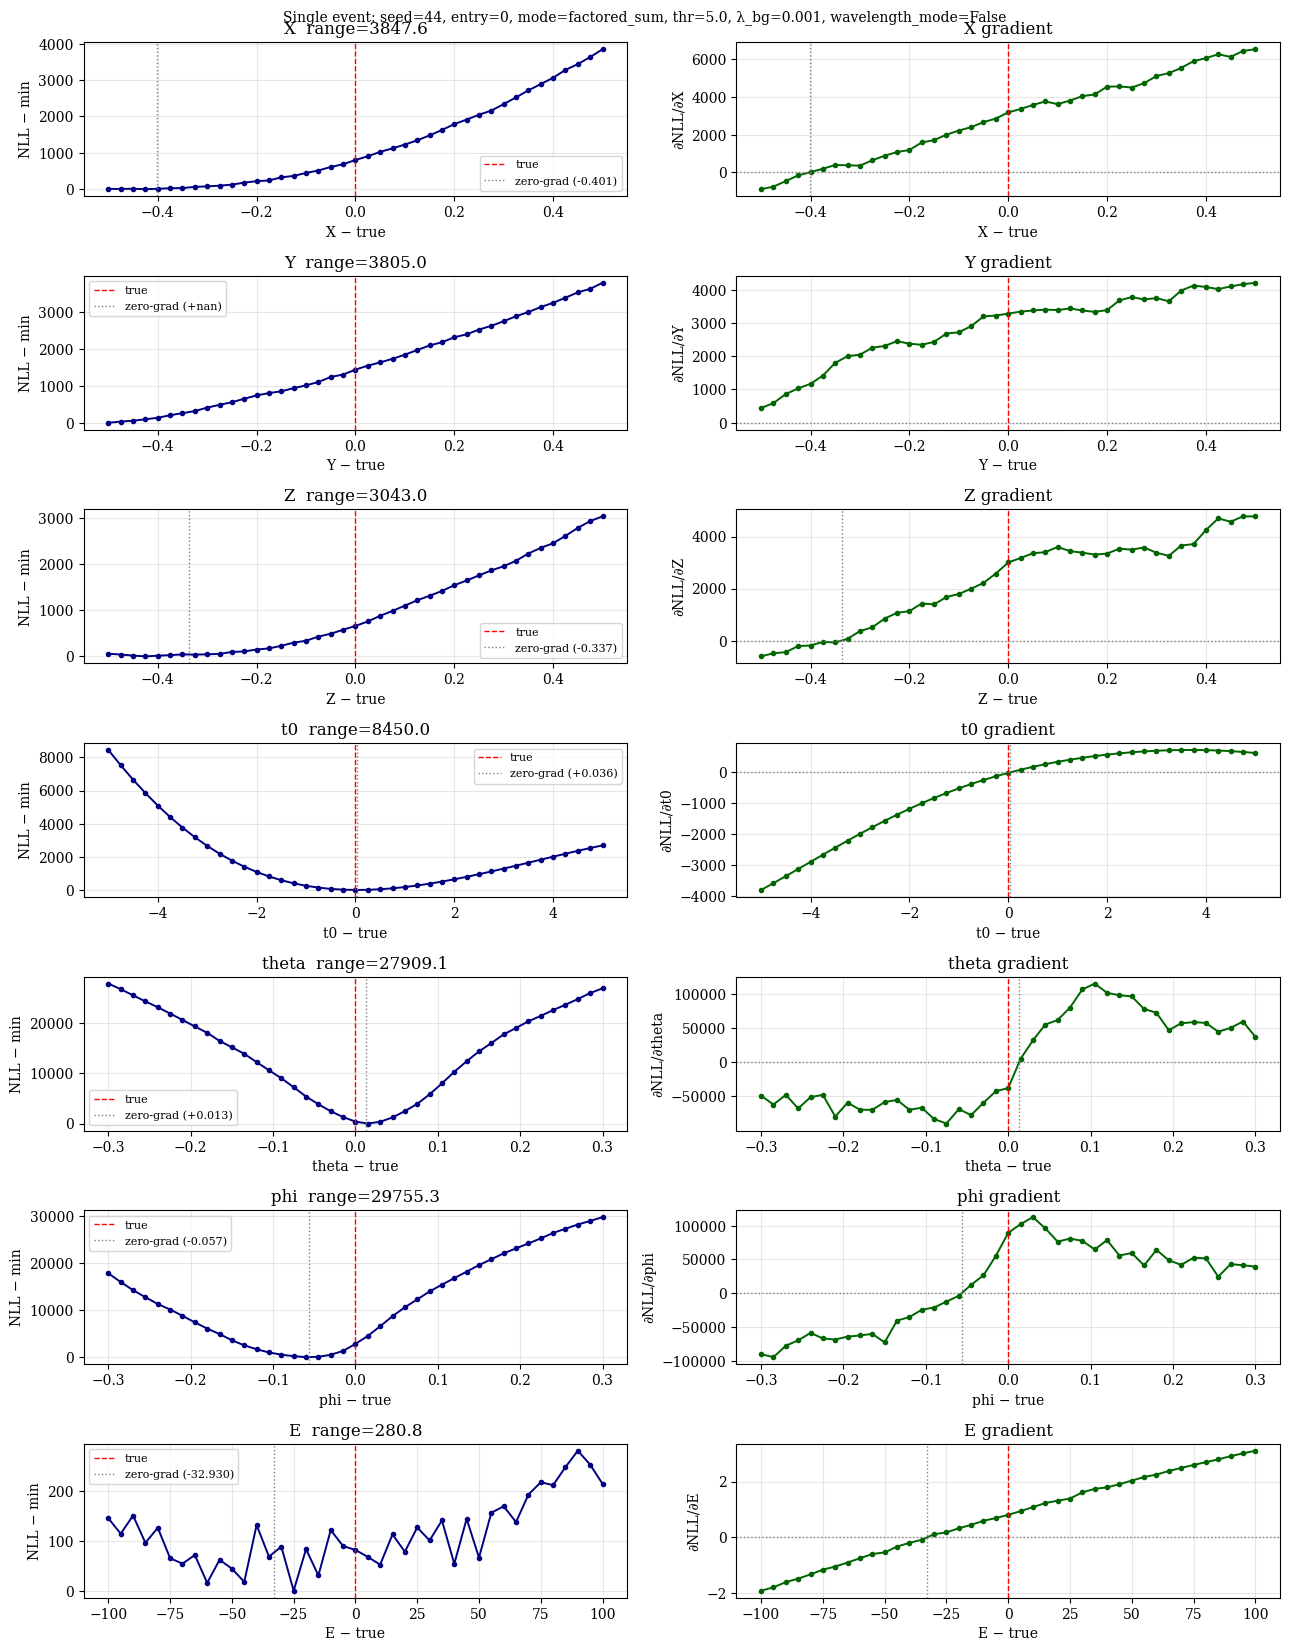

In [8]:
# Scan and plot
scan_specs = meb.SCAN_SPECS  # [(name, idx, range), ...]
results = []
for name, idx, scan_rng in scan_specs:
    r = perform_scan(loss_and_grad, true_param_values, true_data,
                      name, idx, scan_rng, n_points=N_SCAN,
                      mode=MODE, hit_threshold=HIT_THRESHOLD,
                      lambda_bg=LAMBDA_BG)
    i_min = int(np.argmin(r['losses']))
    zero_off, slope = meb.find_grad_zero_crossing(r['values'], r['gradients'], r['true'])
    rng_loss = float(r['losses'].max() - r['losses'].min())
    results.append((name, r, zero_off, slope, rng_loss))
    print(f'  {name:>6}: zero-grad offset = {zero_off:+.4f}, '
          f'argmin offset = {r["values"][i_min] - r["true"]:+.4f}, '
          f'range = {rng_loss:.1f}')

n = len(results)
fig, axes = plt.subplots(n, 2, figsize=(13, 2.4 * n))
for row, (name, r, zero_off, slope, rng_loss) in enumerate(results):
    ax_l, ax_g = axes[row, 0], axes[row, 1]
    ax_l.plot(r['values'] - r['true'], r['losses'] - r['losses'].min(),
              color='navy', marker='o', markersize=3, lw=1.4)
    ax_l.axvline(0.0, color='red', ls='--', lw=1.0, label='true')
    ax_l.axvline(zero_off, color='gray', ls=':', lw=1.0,
                  label=f'zero-grad ({zero_off:+.3f})')
    ax_l.set_ylabel('NLL − min'); ax_l.set_xlabel(f'{name} − true')
    ax_l.grid(alpha=0.3); ax_l.legend(fontsize=8); ax_l.set_title(f'{name}  range={rng_loss:.1f}')

    ax_g.plot(r['values'] - r['true'], r['gradients'],
               color='darkgreen', marker='o', markersize=3, lw=1.4)
    ax_g.axhline(0.0, color='gray', ls=':', lw=1.0)
    ax_g.axvline(0.0, color='red', ls='--', lw=1.0)
    ax_g.axvline(zero_off, color='gray', ls=':', lw=1.0)
    ax_g.set_ylabel(f'∂NLL/∂{name}'); ax_g.set_xlabel(f'{name} − true')
    ax_g.grid(alpha=0.3); ax_g.set_title(f'{name} gradient')

fig.suptitle(f'Single event: seed={SEED_SHOW}, entry={ENTRY_SHOW}, '
             f'mode={MODE}, thr={HIT_THRESHOLD}, λ_bg={LAMBDA_BG}, '
             f'wavelength_mode={WAVELENGTH_MODE}', fontsize=10)
plt.tight_layout()
plt.show()


## 3. Multi-event bias sweep (secant)

Runs the secant solver for each parameter across 50 (seed, entry) pairs. Per
parameter we record the gradient zero-crossing offset, then aggregate across
events. The histogram shows the distribution of biases per param.


In [9]:
# Warmup grad_fn
t0 = time.time()
e_warm = jnp.zeros(7, dtype=jnp.float32).at[0].set(1.0)
cw, tw, gm, jt, fac = _MODE_PARAMS[MODE]
_ = grad_fn(jnp.float32(0.0),
              jnp.array(true_param_values, dtype=jnp.float32),
              e_warm, hit_times, hit_counts, jax.random.PRNGKey(42),
              jnp.float32(cw), jnp.float32(tw),
              jnp.float32(HIT_THRESHOLD), jnp.float32(LAMBDA_BG),
              jnp.float32(gm), jnp.float32(jt), jnp.float32(fac))
print(f'  grad_fn warmup: {time.time() - t0:.1f}s')

per_param = {name: [] for name, _, _ in scan_specs}
raw_events = []
for ev in range(N_EVENTS):
    entry_idx = START_ENTRY + ev
    seed = SEED_BASE + ev
    (true_track, true_data, x, y, z, theta, phi, energy) = meb.build_event_for_entry(
        detector, data_sim, num_detectors, entry_idx=entry_idx, seed=seed)
    true_pv = [x, y, z, 0.0, theta, phi, energy]
    base_params = jnp.array(true_pv, dtype=jnp.float32)
    ev_out = meb.run_one_event_secant(
        grad_fn, base_params, true_data,
        hit_threshold=HIT_THRESHOLD, lambda_bg=LAMBDA_BG, mode=MODE)
    for name, _, _ in scan_specs:
        per_param[name].append(ev_out[name])
    raw_events.append({'event_idx': ev, 'entry_idx': entry_idx, 'seed': seed,
                         'true_param_values': true_pv, 'scans': ev_out})
    if (ev + 1) % 10 == 0 or ev == 0:
        print(f'  event {ev + 1}/{N_EVENTS}')

meb.print_summary_table(per_param, MODE, HIT_THRESHOLD, LAMBDA_BG, N_EVENTS)


  grad_fn warmup: 17.8s
  event 1/20
  event 10/20
  event 20/20

 SUMMARY  •  mode=factored_sum  •  thr ≥ 5.0 PE  •  λ_bg = 1e-03  •  20 events
 param | argmin_  mean  zero_  mean  slope_  mean | argmin_   std  zero_   std  slope_   std | argmin_median  zero_median  slope_median | argmin_   iqr  zero_   iqr  slope_   iqr | n
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
     X |       +nan     -0.0420  +9547.6397 |       +nan     +0.1188  +133756.4208 |       +nan     +0.0028  +10881.2358 |       +nan     +0.1034  +56722.5099 | 20
     Y |       +nan     -0.0279  -186379.7667 |       +nan     +0.1830  +707817.3908 |       +nan     -0.0289  +9542.7494 |       +nan     +0.1551  +95260.2022 | 20
     Z |       +nan     +0.0342  +595214.8253 |       +nan     +0.1907  +2657979.0029 |       +nan     +0.0000  +9416.4906 |       +nan     +0.0961  +32576.6966

saved: figures/multi_event_bias/nb_bias_hist_factored_sum_thr5.0_n20.png


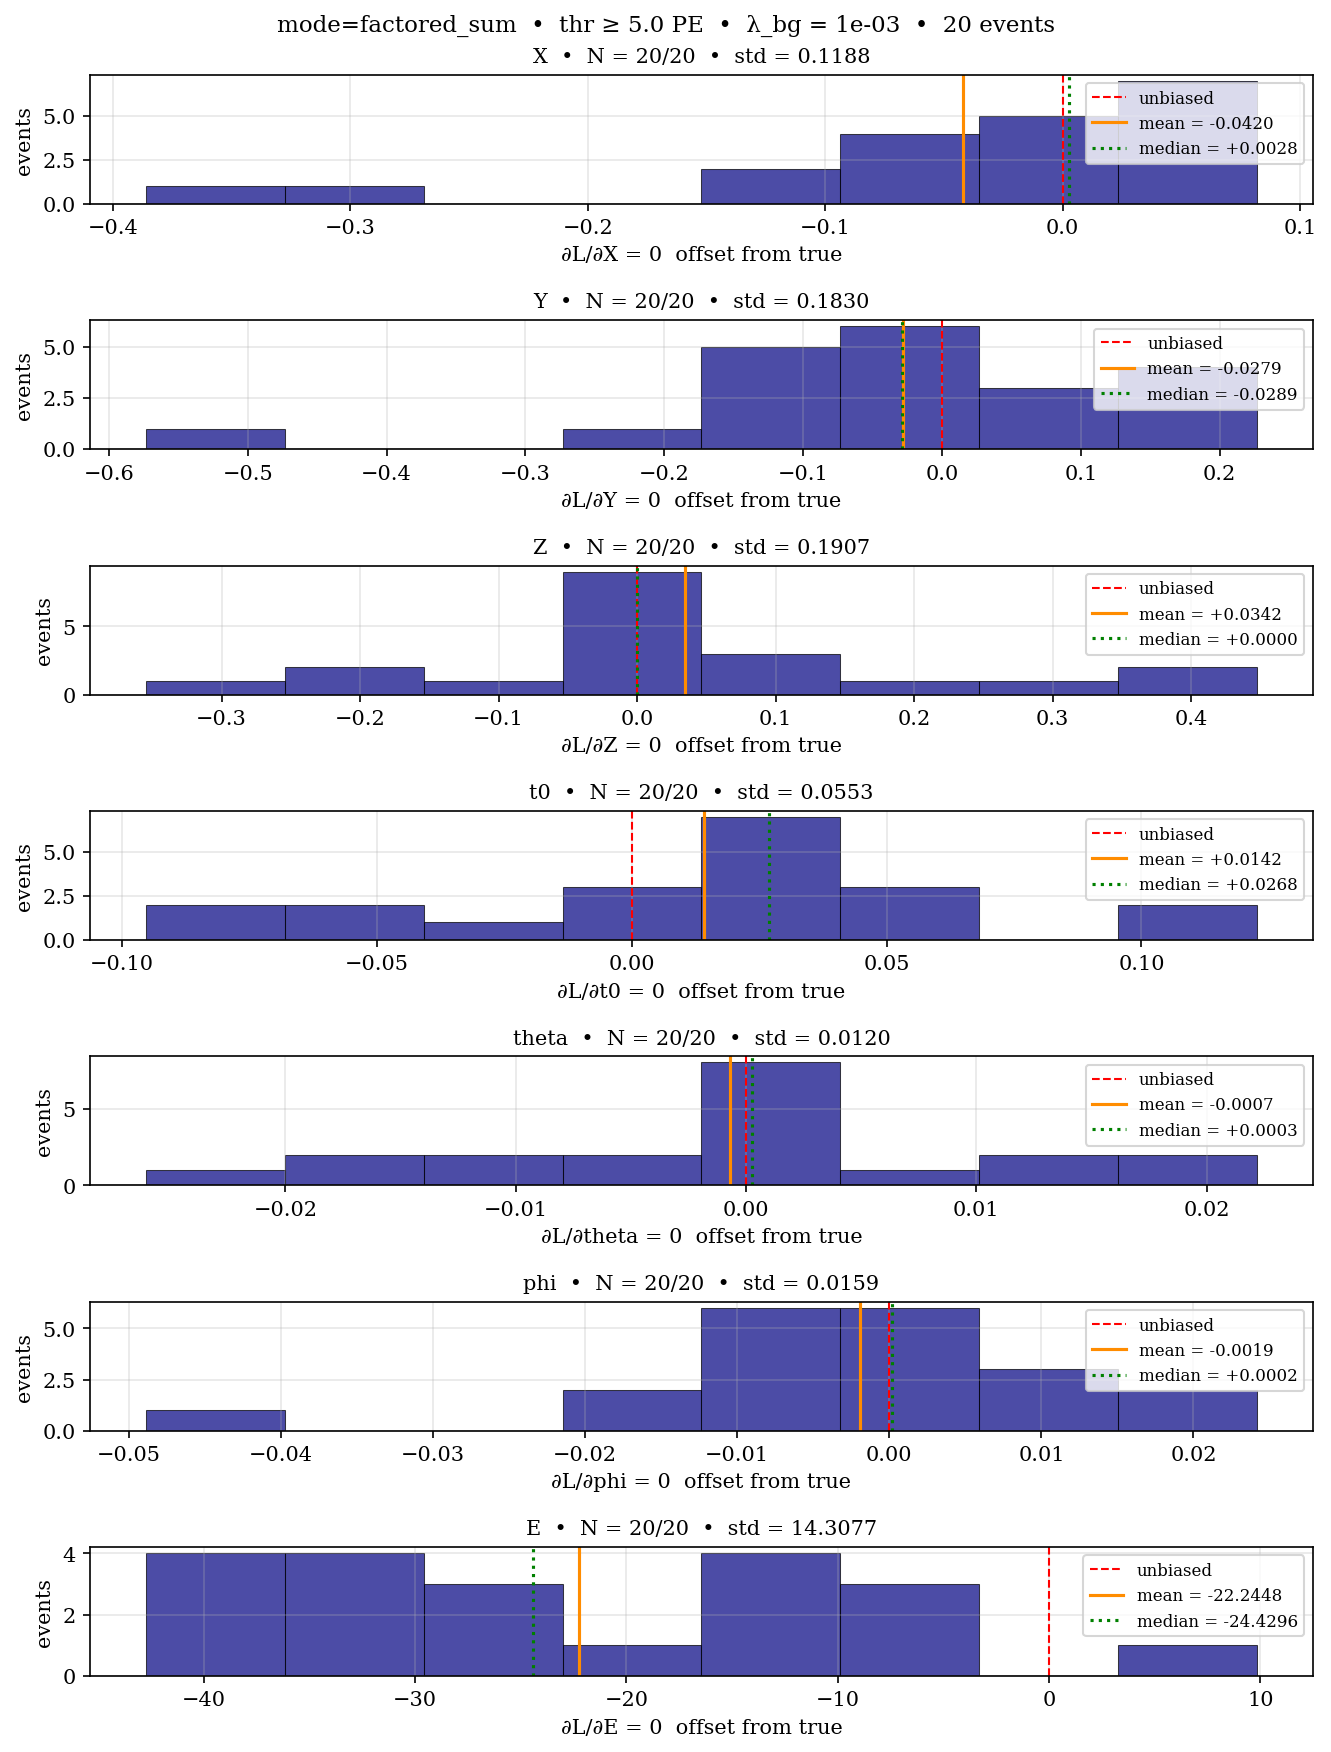

In [10]:
# Histograms of zero-grad bias per parameter
per_param_zeros = {name: [e['grad_zero_offset'] for e in per_param[name]]
                     for name, _, _ in scan_specs}
out_dir = Path('figures/multi_event_bias')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f'nb_bias_hist_{MODE}_thr{HIT_THRESHOLD:.1f}_n{N_EVENTS}.png'
meb.plot_bias_histograms(per_param_zeros, MODE, HIT_THRESHOLD,
                          LAMBDA_BG, N_EVENTS, out_path)
print(f'saved: {out_path}')
# Inline display
from IPython.display import Image
Image(filename=str(out_path))


## 4. Mode comparison: `joint` vs `factored_sum`

Re-run the same N events under both modes for direct comparison. `joint` applies
hit_threshold to every term so it loses Poisson-zero info from unhit sensors;
`factored_sum` sums charge over all sensors. The E bias typically flips sign
between the two.


In [ ]:
def run_mode(mode_name):
    per_param_m = {name: [] for name, _, _ in scan_specs}
    for ev in range(N_EVENTS):
        entry_idx = START_ENTRY + ev
        seed = SEED_BASE + ev
        (_, true_data, x, y, z, theta, phi, energy) = meb.build_event_for_entry(
            detector, data_sim, num_detectors, entry_idx=entry_idx, seed=seed)
        bp = jnp.array([x, y, z, 0.0, theta, phi, energy], dtype=jnp.float32)
        ev_out = meb.run_one_event_secant(
            grad_fn, bp, true_data,
            hit_threshold=HIT_THRESHOLD, lambda_bg=LAMBDA_BG, mode=mode_name)
        for name, _, _ in scan_specs:
            per_param_m[name].append(ev_out[name])
    return per_param_m

print('Running joint ...')
pp_joint = run_mode('joint')
print('Running factored_sum ...')
pp_fs = run_mode('factored_sum')

print()
print(f'{"param":>6} | {"joint mean ± SE":>20} | {"factored_sum mean ± SE":>26}')
print('-' * 60)
for name, _, _ in scan_specs:
    a = np.asarray([e['grad_zero_offset'] for e in pp_joint[name]], dtype=float)
    b = np.asarray([e['grad_zero_offset'] for e in pp_fs[name]], dtype=float)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    sa = float(np.std(a, ddof=1)/np.sqrt(len(a))) if len(a) > 1 else 0.0
    sb = float(np.std(b, ddof=1)/np.sqrt(len(b))) if len(b) > 1 else 0.0
    print(f'{name:>6} | {a.mean():+10.4f} ± {sa:7.4f}    '
          f'| {b.mean():+10.4f} ± {sb:7.4f}')


Running joint ...


## 5. Source decomposition

For each event, run pred_sim and data_sim at true parameters and compare totals.
The ratio ΣN_pred / ΣN_data tells you the data/pred calibration offset that the
E bias is chasing.


In [ ]:
# Use sim_total_compare's helpers
print(f'Using wavelength_mode={WAVELENGTH_MODE} for both sims (matches setup).')
ratios, sums_data, sums_pred = [], [], []
pred_key = jax.random.PRNGKey(42)
for ev in range(N_EVENTS):
    entry_idx = START_ENTRY + ev
    seed = SEED_BASE + ev
    (true_track, true_data, x, y, z, theta, phi, energy) = meb.build_event_for_entry(
        detector, data_sim, num_detectors, entry_idx=entry_idx, seed=seed)
    sum_d = float(np.sum(np.asarray(true_data[0])))
    out_p = pred_sim(true_track, pred_key)
    sum_p = float(np.sum(np.asarray(out_p[3])))
    ratios.append(sum_p / sum_d)
    sums_data.append(sum_d)
    sums_pred.append(sum_p)
ratios = np.asarray(ratios)
sums_data = np.asarray(sums_data)
sums_pred = np.asarray(sums_pred)
print(f'ΣN_data    : {sums_data.mean():.1f} ± {sums_data.std(ddof=1):.1f}')
print(f'ΣN_pred    : {sums_pred.mean():.1f} ± {sums_pred.std(ddof=1):.1f}')
print(f'ratio      : {ratios.mean():.4f} ± {ratios.std(ddof=1):.4f}')
implied_e_bias = 1050.0 * (1.0 / ratios - 1.0)
print(f'implied E bias = {implied_e_bias.mean():+.1f} ± '
      f'{implied_e_bias.std(ddof=1)/np.sqrt(N_EVENTS):.1f} MeV (SE of mean)')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(ratios, bins=20, color='C0', alpha=0.7, edgecolor='black')
ax[0].axvline(1.0, color='red', ls='--')
ax[0].axvline(ratios.mean(), color='darkorange', ls='-')
ax[0].set_xlabel('ΣN_pred / ΣN_data')
ax[0].set_ylabel('events')
ax[0].set_title('Pred/Data total-charge ratio per event')
ax[0].grid(alpha=0.3)
ax[1].scatter(sums_data, sums_pred, alpha=0.6)
mn, mx = min(sums_data.min(), sums_pred.min()), max(sums_data.max(), sums_pred.max())
ax[1].plot([mn, mx], [mn, mx], 'k--', lw=0.7, label='y = x')
ax[1].set_xlabel('ΣN_data'); ax[1].set_ylabel('ΣN_pred')
ax[1].set_title('Per-event ΣN_data vs ΣN_pred')
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 6. Calibration: needed `tot_n_photons_normalization`

Compute the needed `total_norm` at E=1050 separately for "match emission" and
"match detection". If they differ, distribution shape (not just total) matters
beyond a global gain calibration.


In [ ]:
importlib.reload(ctn)
# This calls the same script function but we'll do it inline for the notebook
from lucid.utils import unpack_photonsim_params
from lucid.siren.training.inference import SIRENPredictor
from lucid.siren.core import create_photonsim_siren_grid
from lucid.sources.siren_rays import photonsim_differentiable_get_rays
from lucid.generate import read_photon_data_from_photonsim
from parameter_scans_1D_gaussian import DATA_FILE

params = unpack_photonsim_params('muon', 'water')
a, b, c = params['tot_n_photons_normalization']
sa, sb, sc = params['num_seeds']
ENERGY_REF = 1050.0
fit_total_norm = a * ENERGY_REF**b + c

predictor = SIRENPredictor(params['siren_model_path'])
grid_data = create_photonsim_siren_grid(predictor)
model_params = predictor.params
# SIREN mean weight at E_ref (deterministic for fixed key)
_, _, ws = photonsim_differentiable_get_rays(
    jnp.zeros(3), jnp.array([0., 0., 1.]), ENERGY_REF, NPHOT_PRED,
    grid_data, model_params, jax.random.PRNGKey(42), sa, sb, sc)
siren_mw = float(np.mean(np.asarray(ws)))

# Per-event needed_norm to match EMISSION and DETECTION
needed_emit, needed_det = [], []
for ev in range(N_EVENTS):
    entry_idx = START_ENTRY + ev
    seed = SEED_BASE + ev
    pd = read_photon_data_from_photonsim(DATA_FILE, entry_idx)
    n_phsim = int(len(pd['photon_origins']))
    needed_emit.append(n_phsim / siren_mw)
    needed_det.append(fit_total_norm * sums_data[ev] / sums_pred[ev])
needed_emit = np.asarray(needed_emit)
needed_det  = np.asarray(needed_det)

print(f'fit  total_norm(1050)              = {fit_total_norm:>10.2f}')
print(f'needed total_norm — match emission = {needed_emit.mean():>10.2f} ± '
      f'{needed_emit.std(ddof=1):.2f}  ({100*(fit_total_norm/needed_emit.mean()-1):+.2f} % off)')
print(f'needed total_norm — match detect.  = {needed_det.mean():>10.2f} ± '
      f'{needed_det.std(ddof=1):.2f}  ({100*(fit_total_norm/needed_det.mean()-1):+.2f} % off)')
print(f'gap (distribution-shape effect)    = {100*(needed_emit.mean()/needed_det.mean()-1):+.2f} %')


## Notes

- Heavy logic lives in scripts: `parameter_scans_1D_gaussian.py`, `multi_event_bias_joint.py`,
  `sim_total_compare.py`, `distribution_compare.py`, `check_total_norm.py`.
- To compare a different loss mode, change `MODE` at the top.
- To toggle wavelength-dependent optics, change `WAVELENGTH_MODE` and rebuild simulators.
- For richer per-event detail (full scan-grid arrays per param), use `--solver scan`
  in the CLI version of `multi_event_bias_joint.py`.
